### Environment Setup

In [1]:
import math
import os
import numpy as np
import cv2

### Location Estimation of Objects using a Single Image and GPS

In [4]:
def intrinsics_from_fov(W, H, fov_x_deg):
  '''
  Converts FOV and resolution into an intrinsic matrix.
  '''

  fov_x = math.radians(fov_x_deg)

  fx = (W / 2.0) / math.tan(fov_x / 2.0)
  
  fy = fx

  cx = W / 2.0
  cy = H / 2.0

  K = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
  ], dtype=float)

  return K

In [5]:
def rot_from_unreal(pitch_deg, yaw_deg, roll_deg):
  '''
  It generates a rotation matrix to transform the camera's frame of reference into the frame of reference of the world.
  '''

  yaw = math.radians(yaw_deg)
  pitch = math.radians(pitch_deg)
  roll = math.radians(roll_deg)

  cy, sy = math.cos(yaw), math.sin(yaw)
  cp, sp = math.cos(pitch), math.sin(pitch)
  cr, sr = math.cos(roll), math.sin(roll)

  Rz = np.array([
    [cy, -sy, 0],
    [sy,  cy, 0],
    [0,   0,  1]
  ])

  Ry = np.array([
    [cp, 0, sp],
    [0,  1, 0],
    [-sp,0, cp]
  ])

  Rx = np.array([
    [1, 0, 0],
    [0, cr, -sr],
    [0, sr,  cr]
  ])

  return Rz @ Ry @ Rx

In [6]:
def ray_from_pixel_unreal(u, v, K, R_wc):
    '''
    Transforms a 2D point into a 3D ray.
    '''
    fx = K[0, 0]
    fy = K[1, 1]
    cx = K[0, 2]
    cy = K[1, 2]

    x = (u - cx) / fx
    y = (v - cy) / fy

    ray_cam = np.array([1.0, -x, y], dtype=float)
    ray_cam /= np.linalg.norm(ray_cam)

    ray_world = R_wc @ ray_cam
    ray_world /= np.linalg.norm(ray_world)
    return ray_world

In [2]:
def read_telemetry(telemetry_data):
    with open(telemetry_data, "r") as f:
        line = f.readline().strip()

    values = list(map(float, line.split()))

    if len(values) != 6:
        raise ValueError(f"Telemetry invalid: {telemetry_data}")

    return tuple(values)  # (x, y, z, pitch, yaw, roll)

In [3]:
def read_labels(label_file):
    labels = []

    with open(label_file, "r") as f:
        for line in f:
            values = list(map(float, line.strip().split()))

            if len(values) != 5:
                continue 

            cls, xc, yc, w, h = values
            labels.append((int(cls), xc, yc, w, h))

    return labels # (cls, x, y, w, h)

In [10]:
# Main Function:
def localize_objects(labels_file, telemetry_data, W=1280, H=720, fov_x=90): 
    ''' 
    output: obj = { "id": int, "class": "person", "position": np.array([x, y, z]) } 
    ''' 

    results = [] 
    
    labels = read_labels(labels_file) 
    
    x, y, z, pitch, yaw, roll = read_telemetry(telemetry_data) 
    
    C = np.array([x, y, z]) 
    R_wc = rot_from_unreal(pitch, -yaw, roll) 
    K = intrinsics_from_fov(W, H, fov_x) 
    
    for obj_id, (cls, xc, yc, w, h) in enumerate(labels): 
        cls = int(cls) 
        
        if cls not in [0, 1, 2, 3]: 
            continue 
        
        u = xc * W 
        v = (yc + h/2) * H 
        d = ray_from_pixel_unreal(u, v, K, R_wc) 
        
        if abs(d[2]) < 1e-6: 
            continue 
        
        t = -C[2] / d[2] 
        P = C + t * d 
        
        if cls == 0: 
            name = "person" 
        elif cls == 1: 
            name = "normal_vehicle" 
        elif cls == 2: 
            name = "emergency_vehicle" 
        else: name = "fire" 
        
        results.append({ "id": obj_id, "class": name, "position": P }) 
    
    return results

In [11]:
img_dir = "../data/results/annotated_imgs"
label_dir = "../data/results/labels"
pose_dir = "../data/telemetryData"

for img_name in os.listdir(img_dir):

    if not img_name.endswith((".png", ".jpg", ".jpeg")):
        continue

    base = os.path.splitext(img_name)[0]

    labels = os.path.join(label_dir, base + ".txt")
    telemetry = os.path.join(pose_dir, base + ".txt")

    if not os.path.exists(labels) or not os.path.exists(telemetry):
        continue

    objects = localize_objects(labels, telemetry)

    print(f"\n=== {img_name} ===")
    for obj in objects:
        if obj['class'] == "fire":
            continue
        
        P = obj["position"]
        print(f"ID: {obj['id']:>1} | {obj['class']} -> ({P[0]:.2f}, {P[1]:.2f})")


=== 00000.png ===
ID: 0 | person -> (-240.10, -29.12)
ID: 1 | person -> (-230.67, -46.61)
ID: 2 | normal_vehicle -> (-231.01, -28.75)
ID: 3 | normal_vehicle -> (-231.35, -36.38)
ID: 4 | normal_vehicle -> (-232.26, -40.52)
ID: 5 | emergency_vehicle -> (-226.64, -50.97)

=== 00001.png ===
ID: 0 | person -> (-251.03, -25.69)
ID: 1 | person -> (-253.81, -54.53)
ID: 2 | person -> (-251.01, -38.18)
ID: 3 | person -> (-247.53, -49.48)
ID: 4 | normal_vehicle -> (-231.93, -31.22)
ID: 5 | normal_vehicle -> (-243.15, -24.32)
ID: 6 | normal_vehicle -> (-231.45, -22.43)
ID: 7 | emergency_vehicle -> (-239.75, -48.17)

=== 00002.png ===
ID: 0 | person -> (-267.15, -38.69)
ID: 1 | person -> (-267.85, -49.33)
ID: 2 | person -> (-269.39, -29.23)
ID: 3 | person -> (-261.44, -44.16)
ID: 4 | normal_vehicle -> (-258.99, -29.01)
ID: 5 | normal_vehicle -> (-261.46, -44.18)
ID: 6 | normal_vehicle -> (-259.61, -38.11)

=== 00003.png ===
ID: 0 | person -> (-247.27, -53.91)
ID: 1 | person -> (-242.71, -49.64)
ID

#### Localization Confidence per Axis

Each localized object receives a confidence score in $[0,1]$ for each world axis, representing the geometric conditioning of the ground-plane projection. Given the ground intersection $P=C+td$, with $t=-C_z/d_z$, the sensitivity of the estimated position to pixel errors is measured through the Jacobian $J$, whose rows $\mathbf{j}_x$ and $\mathbf{j}_y$ describe the effect of image perturbations on the world $X$ and $Y$ axes. The geometric confidence is computed by comparing this sensitivity with the ideal nadir sensitivity $|C_z|/f_x$:

$$
\text{conf}^{geo}_x =
\min\left(1,\frac{|C_z|/f_x}{\|\mathbf{j}_x\|}\right),
\qquad
\text{conf}^{geo}_y =
\min\left(1,\frac{|C_z|/f_x}{\|\mathbf{j}_y\|}\right)
$$


In [ ]:
def localization_confidence(u, v, C, K, R_wc, bbox_w_px, bbox_h_px, class_name):
    '''
    Per-axis confidence of the ground-plane projection of (u, v).

    It combines:
      1) geometric conditioning (Jacobian-based), and
      2) point-selection reliability (how uncertain bottom-center is as a
         real contact/reference point, estimated from bbox size and class).
    '''
    def _project(uu, vv):
        d = ray_from_pixel_unreal(uu, vv, K, R_wc)
        return C + (-C[2] / d[2]) * d

    eps = 0.5
    P0 = _project(u, v)
    dPdu = (_project(u + eps, v) - P0) / eps
    dPdv = (_project(u, v + eps) - P0) / eps

    sens_x = float(np.hypot(dPdu[0], dPdv[0]))
    sens_y = float(np.hypot(dPdu[1], dPdv[1]))

    # 1) Geometric conditioning term
    ref = abs(float(C[2])) / float(K[0, 0])
    conf_geom_x = float(min(1.0, ref / max(sens_x, 1e-12)))
    conf_geom_y = float(min(1.0, ref / max(sens_y, 1e-12)))

    # 2) Point-selection term
    sigma_u_det = max(1.0, 0.02 * bbox_w_px)
    sigma_v_det = max(2.0, 0.06 * bbox_h_px)

    if class_name in ("normal_vehicle", "emergency_vehicle"):
        sigma_u_pick = max(5.0, 0.10 * bbox_w_px)
        sigma_v_pick = max(6.0, 0.16 * bbox_h_px)
    elif class_name == "person":
        sigma_u_pick = max(1.5, 0.03 * bbox_w_px)
        sigma_v_pick = max(3.0, 0.10 * bbox_h_px)
    else:
        sigma_u_pick = max(2.0, 0.05 * bbox_w_px)
        sigma_v_pick = max(4.0, 0.12 * bbox_h_px)

    sigma_u = float(math.hypot(sigma_u_det, sigma_u_pick))
    sigma_v = float(math.hypot(sigma_v_det, sigma_v_pick))

    q_u = 1.0 / (1.0 + sigma_u / 8.0)
    q_v = 1.0 / (1.0 + sigma_v / 10.0)

    conf_x = float(conf_geom_x * q_u)
    conf_y = float(conf_geom_y * q_v)

    return {
        "confidence_x": conf_x,
        "confidence_y": conf_y,
    }

In [ ]:
def localize_objects_with_confidence(labels_file, telemetry_data, W=1280, H=720, fov_x=90):
    results = []

    labels = read_labels(labels_file)
    x, y, z, pitch, yaw, roll = read_telemetry(telemetry_data)

    C = np.array([x, y, z], dtype=float)
    R_wc = rot_from_unreal(pitch, -yaw, roll)
    K = intrinsics_from_fov(W, H, fov_x)

    for obj_id, (cls, xc, yc, w, h) in enumerate(labels):
        cls = int(cls)

        if cls not in [0, 1, 2, 3]:
            continue

        u = xc * W
        v = (yc + h / 2) * H

        d = ray_from_pixel_unreal(u, v, K, R_wc)
        if abs(d[2]) < 1e-6:
            continue

        t = -C[2] / d[2]
        P = C + t * d

        if cls == 0:
            name = "person"
        elif cls == 1:
            name = "normal_vehicle"
        elif cls == 2:
            name = "emergency_vehicle"
        else:
            name = "fire"

        q = localization_confidence(
            u, v, C, K, R_wc,
            bbox_w_px=w * W,
            bbox_h_px=h * H,
            class_name=name,
        )

        results.append({
            "id": obj_id,
            "class": name,
            "position": P,
            "confidence_x": q["confidence_x"],
            "confidence_y": q["confidence_y"],
        })

    return results

In [23]:
img_dir = "../data/results/annotated_imgs"
label_dir = "../data/results/labels"
pose_dir = "../data/telemetryData"

for img_name in sorted(os.listdir(img_dir))[:5]:

    if not img_name.endswith((".png", ".jpg", ".jpeg")):
        continue

    base = os.path.splitext(img_name)[0]
    labels = os.path.join(label_dir, base + ".txt")
    telemetry = os.path.join(pose_dir, base + ".txt")

    if not os.path.exists(labels) or not os.path.exists(telemetry):
        continue

    objects = localize_objects_with_confidence(labels, telemetry)

    print(f"\n=== {img_name} ===")
    print(f"{'ID':>2} | {'class':<17} | {'X':>8} {'Y':>8} | "
          f"{'conf_x':>6} {'conf_y':>6}")
    print("-" * 62)

    for obj in objects:
        if obj["class"] == "fire":
            continue
        P = obj["position"]
        print(f"{obj['id']:>2} | {obj['class']:<17} | "
              f"{P[0]:>8.2f} {P[1]:>8.2f} | "
              f"{obj['confidence_x']:>6.2f} {obj['confidence_y']:>6.2f}")


=== 00000.png ===
ID | class             |        X        Y | conf_x conf_y
--------------------------------------------------------------
 0 | person            |  -240.10   -29.12 |   0.82   0.73
 1 | person            |  -230.67   -46.61 |   0.82   0.73
 2 | normal_vehicle    |  -231.01   -28.75 |   0.49   0.33
 3 | normal_vehicle    |  -231.35   -36.38 |   0.48   0.33
 4 | normal_vehicle    |  -232.26   -40.52 |   0.46   0.31
 5 | emergency_vehicle |  -226.64   -50.97 |   0.21   0.17

=== 00001.png ===
ID | class             |        X        Y | conf_x conf_y
--------------------------------------------------------------
 0 | person            |  -251.03   -25.69 |   0.42   0.27
 1 | person            |  -253.81   -54.53 |   0.18   0.07
 2 | person            |  -251.01   -38.18 |   0.28   0.13
 3 | person            |  -247.53   -49.48 |   0.24   0.09
 4 | normal_vehicle    |  -231.93   -31.22 |   0.21   0.14
 5 | normal_vehicle    |  -243.15   -24.32 |   0.31   0.21
 6 | norma

#### Distance to fire

In [32]:
def compute_distance_to_fire(objects):

    fire_objects = [o for o in objects if o["class"] == "fire"]
    results = []

    if not fire_objects:
        for obj in objects:
            results.append({
                "class": obj["class"],
                "position": obj["position"],
                "distance_to_fire": None
            })
        return results

    for obj in objects:

        if obj["class"] == "fire":
            continue  

        min_dist = float("inf")

        for fire in fire_objects:
            d = np.linalg.norm(obj["position"] - fire["position"])
            if d < min_dist:
                min_dist = d

        results.append({
            "class": obj["class"],
            "position": obj["position"],
            "distance_to_fire": min_dist
        })

    return results

In [51]:
img_dir = "../data/results/annotated_imgs"
label_dir = "../data/results/labels"
pose_dir = "../data/telemetryData"

for img_name in os.listdir(img_dir):

    if not img_name.endswith((".png", ".jpg", ".jpeg")):
        continue

    base = os.path.splitext(img_name)[0]

    labels = os.path.join(label_dir, base + ".txt")
    telemetry = os.path.join(pose_dir, base + ".txt")

    if not os.path.exists(labels) or not os.path.exists(telemetry):
        continue

    objects = localize_objects(labels, telemetry)

    distance = compute_distance_to_fire(objects)

    print("\n" + "="*58)
    print(f"IMAGE: {img_name}")
    print("="*58)

    print(f"{'Class':<18} | {'X':>7} {'Y':>7} {'Z':>7} | {'DistFire':>10}")
    print("-"*58)

    for obj in distance:
        P = obj["position"]
        d = obj["distance_to_fire"]

        print(
            f"{obj['class']:<18} | "
            f"{P[0]:8.2f} {P[1]:8.2f} {P[2]:5.2f} | "
            f"{(f'{d:.2f}' if d is not None else 'N/A'):>10}"
        )


IMAGE: 00000.png
Class              |       X       Y       Z |   DistFire
----------------------------------------------------------
person             |  -219.11   -29.12  0.00 |      13.05
person             |  -228.73   -46.63  0.00 |       0.33
normal_vehicle     |  -228.32   -28.75  0.00 |       7.29
normal_vehicle     |  -228.01   -36.39  0.00 |       2.43
normal_vehicle     |  -227.11   -40.56  0.00 |       4.15
emergency_vehicle  |  -232.76   -50.89 -0.00 |       5.54

IMAGE: 00001.png
Class              |       X       Y       Z |   DistFire
----------------------------------------------------------
person             |  -278.94   -72.25 -0.00 |      42.25
person             |  -245.62   -29.10  0.00 |      15.46
person             |  -250.60   -37.13  0.00 |       8.16
person             |  -243.36   -30.83  0.00 |      14.16
normal_vehicle     |  -228.63   -50.28  0.00 |      19.34
normal_vehicle     |  -262.45   -93.26  0.00 |      51.13
normal_vehicle     |  -188.54  -18

### Id per detection

In [ ]:
def draw_bboxes_with_ids(image_path, label_path):
    img = cv2.imread(image_path)

    if img is None:
        print("Erro ao carregar imagem")
        return None

    H, W = img.shape[:2]
    labels = read_labels(label_path)

    for i, label in enumerate(labels):
        cls, xc, yc, w, h = label

        # YOLO normalizado -> pixel
        x_center = xc * W
        y_center = yc * H
        box_w = w * W
        box_h = h * H

        x1 = int(round(x_center - box_w / 2))
        y1 = int(round(y_center - box_h / 2))
        x2 = int(round(x_center + box_w / 2))
        y2 = int(round(y_center + box_h / 2))

        # limitar à imagem
        x1 = max(0, min(x1, W - 1))
        y1 = max(0, min(y1, H - 1))
        x2 = max(0, min(x2, W - 1))
        y2 = max(0, min(y2, H - 1))

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        cv2.putText(
            img,
            f"ID:{i}",
            (x1, max(0, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 0, 0),
            2
        )

    return img

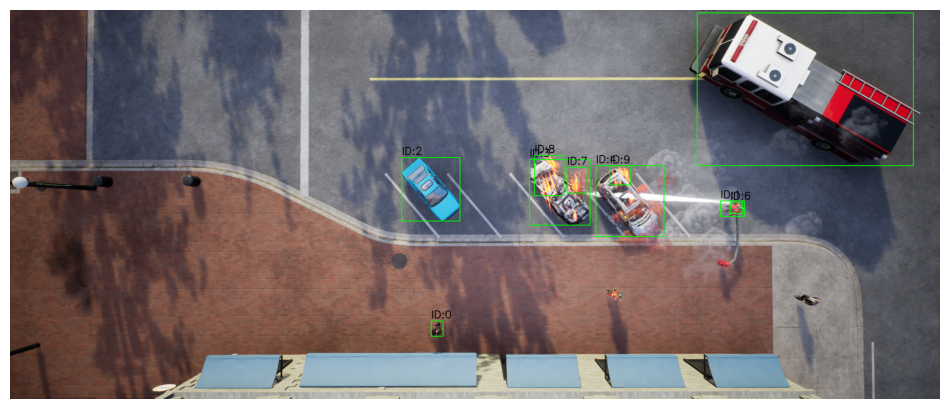

In [10]:
img_out = draw_bboxes_with_ids(
    "../data/daylight_images/00000.png",
    "../data/results/labels/00000.txt"
)

import cv2
import matplotlib.pyplot as plt
from IPython.display import display

img_rgb = cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,9))
plt.imshow(img_rgb)
plt.axis("off")

display(plt.gcf())
plt.close()

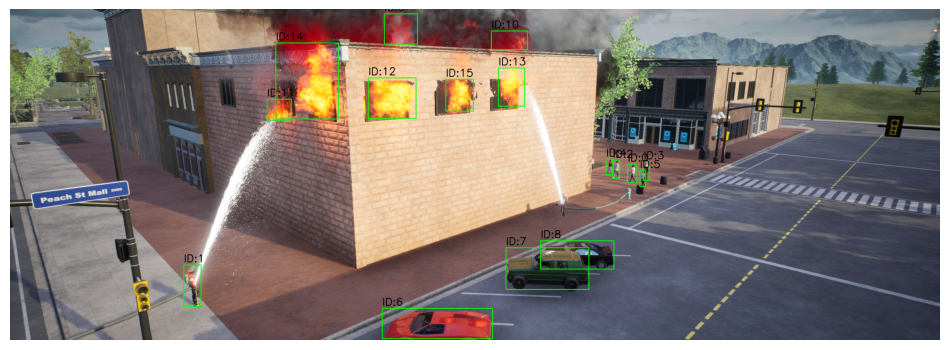

In [7]:
img_out = draw_bboxes_with_ids(
    "../data/daylight_images/00005.png",
    "../data/results/labels/00005.txt"
)

import cv2
import matplotlib.pyplot as plt
from IPython.display import display

img_rgb = cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,9))
plt.imshow(img_rgb)
plt.axis("off")

display(plt.gcf())
plt.close()